# Brain Tumor Detection (BR35H 2020)
Binary image classification on BR35H dataset to detect the presence of brain tumors.  
Uses MobileNetV2 with transfer learning and compares results to a Logistic Regression baseline. 

Notebook workflow:
1. Imports
2. Dataset Splitting
3. Data Augmentation + Loading
4. Visualizing Sample Images
5. Data Loader Setup
6. Model Setup (MobileNetV2)
7. Training Loop
8. CNN Test Set Eval
9. Visualize Test Predictions
10. Logistic Regression for Comparison
11. Train and Evaluate LR
12. Comparison of CNN and LR

## 1. Imports 


In [125]:
import os
import shutil
import random

from tqdm import tqdm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
from torchvision import models
import torch.nn as nn

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

## 2. Dataset Splitting

In [126]:
# Split images into train/validation/test (70/15/15) for each class.
root = "dataset"
yes_dir = os.path.join(root, "yes")
no_dir = os.path.join(root, "no")

target_root = "dataset_split"
splits = ["train", "val", "test"]
for split in splits:
    os.makedirs(os.path.join(target_root, split, "yes"), exist_ok=True)
    os.makedirs(os.path.join(target_root, split, "no"), exist_ok=True)

def split_class(source_dir, class_name):
    images = os.listdir(source_dir)
    random.shuffle(images)
    n = len(images)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)

    for i, img in enumerate(images):
        src = os.path.join(source_dir, img)
        if i < train_end:
            dst = os.path.join(target_root, "train", class_name, img)
        elif i < val_end:
            dst = os.path.join(target_root, "val", class_name, img)
        else:
            dst = os.path.join(target_root, "test", class_name, img)
        shutil.copy(src, dst)

split_class(yes_dir, "yes")
split_class(no_dir, "no")

## 3. Data Augmentation and Loading

In [127]:
#Resize images, apply random flips/rotations, normalize 
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),    
    transforms.RandomRotation(15),        
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data = ImageFolder("dataset_split/train", transform=transform)
val_data = ImageFolder("dataset_split/val", transform=transform)
test_data = ImageFolder("dataset_split/test", transform=transform)

print(len(train_data), len(val_data), len(test_data))
print(train_data.classes)

3000 2407 2412
['no', 'yes']


## 4. Visualize Sample Images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1171243].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping

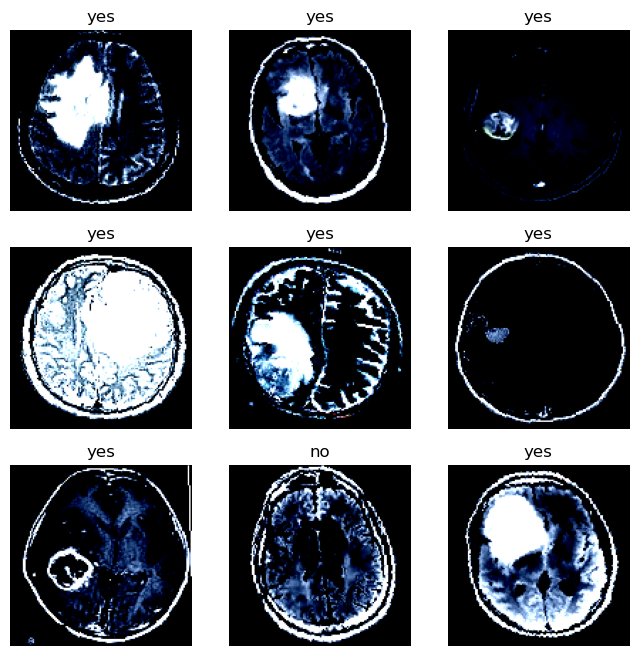

In [128]:
def show_samples(dataset, n=9):
    plt.figure(figsize=(8, 8))
    for i in range(n):
        idx = random.randint(0, len(dataset)-1)
        img, label = dataset[idx]
        plt.subplot(3, 3, i+1)
        plt.imshow(img.permute(1, 2, 0))  
        plt.title(dataset.classes[label])
        plt.axis("off")
    plt.show()
show_samples(train_data)

## 5. Data loader setup

In [129]:
batch_size = 16

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=batch_size, num_workers=0)
test_loader = DataLoader(test_data, batch_size=16, shuffle=True, num_workers=0)

## 6. Model Setup (MobileNetV2)

In [130]:
# Use MPS backend if available (Apple M1 GPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [131]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

#Freeze the base
for param in model.features.parameters():
    param.requires_grad = False

#Unfreeze last 3 blocks
for layer in model.features[-3:]:
    for param in layer.parameters():
        param.requires_grad = True

# Replace the classifier for binary classification
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
model = model.to(device)


## 7. Training Loop
Binary Cross Entropy Loss with logits.
Track accuracy, precision, recall, F1 on train/val.

In [132]:
epochs = 10 
learning_rate = 1e-4

#Criterion + optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=learning_rate
)

#Training loop
for epoch in range(epochs):
    model.train()
    train_losses = []
    all_preds = []
    all_labels = []

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)  # shape [batch, 1]

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        preds = torch.sigmoid(outputs).detach().cpu() >= 0.5
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    #Metrics
    train_acc = accuracy_score(all_labels, all_preds)
    train_prec = precision_score(all_labels, all_preds)
    train_rec = recall_score(all_labels, all_preds)
    train_f1 = f1_score(all_labels, all_preds)

    #Validation
    model.eval()
    val_losses = []
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_losses.append(loss.item())

            preds = torch.sigmoid(outputs).detach().cpu() >= 0.5
            val_preds.extend(preds.numpy())
            val_labels.extend(labels.detach().cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_prec = precision_score(val_labels, val_preds)
    val_rec = recall_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {sum(train_losses)/len(train_losses):.4f} "
          f"Val Loss: {sum(val_losses)/len(val_losses):.4f} "
          f"Train Acc: {train_acc:.4f} Val Acc: {val_acc:.4f} "
          f"F1: {val_f1:.4f}")


100%|██████████| 188/188 [00:11<00:00, 16.72it/s]


Epoch [1/10] Train Loss: 0.2939 Val Loss: 0.1367 Train Acc: 0.8753 Val Acc: 0.9472 F1: 0.9457


100%|██████████| 188/188 [00:08<00:00, 21.08it/s]


Epoch [2/10] Train Loss: 0.1756 Val Loss: 0.1048 Train Acc: 0.9280 Val Acc: 0.9663 F1: 0.9659


100%|██████████| 188/188 [00:08<00:00, 21.04it/s]


...

Epoch [8/10] Train Loss: 0.0641 Val Loss: 0.0237 Train Acc: 0.9793 Val Acc: 0.9921 F1: 0.9921


100%|██████████| 188/188 [00:10<00:00, 18.36it/s]


Epoch [9/10] Train Loss: 0.0740 Val Loss: 0.0236 Train Acc: 0.9727 Val Acc: 0.9925 F1: 0.9926


100%|██████████| 188/188 [00:10<00:00, 17.75it/s]


Epoch [10/10] Train Loss: 0.0765 Val Loss: 0.0173 Train Acc: 0.9747 Val Acc: 0.9950 F1: 0.9950


## 8. Test Set Evaluation
Compute classification report and confusion matrix.
Visualize predictions on test images (denormalized).

Test Set Metrics:
              precision    recall  f1-score   support

          no       1.00      1.00      1.00      1206
         yes       1.00      1.00      1.00      1206

    accuracy                           1.00      2412
   macro avg       1.00      1.00      1.00      2412
weighted avg       1.00      1.00      1.00      2412



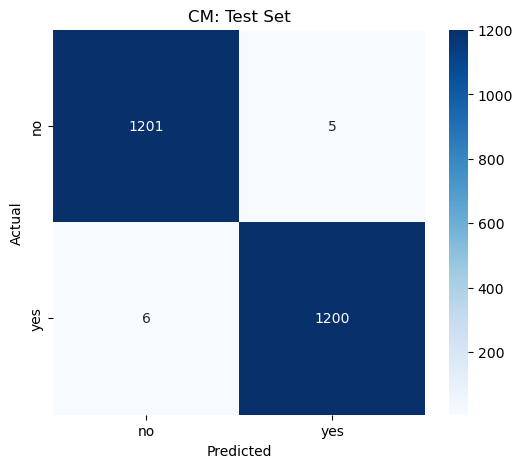

In [133]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        outputs = model(images)
        preds = (torch.sigmoid(outputs) >= 0.5).int()
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

#Classification report 
print("Test Set Metrics:")
print(classification_report(all_labels, all_preds, target_names=train_data.classes))

#Confusion matrix 
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_data.classes,
            yticklabels=train_data.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CM: Test Set")
plt.show()


## 9. Visualize Test Predictions

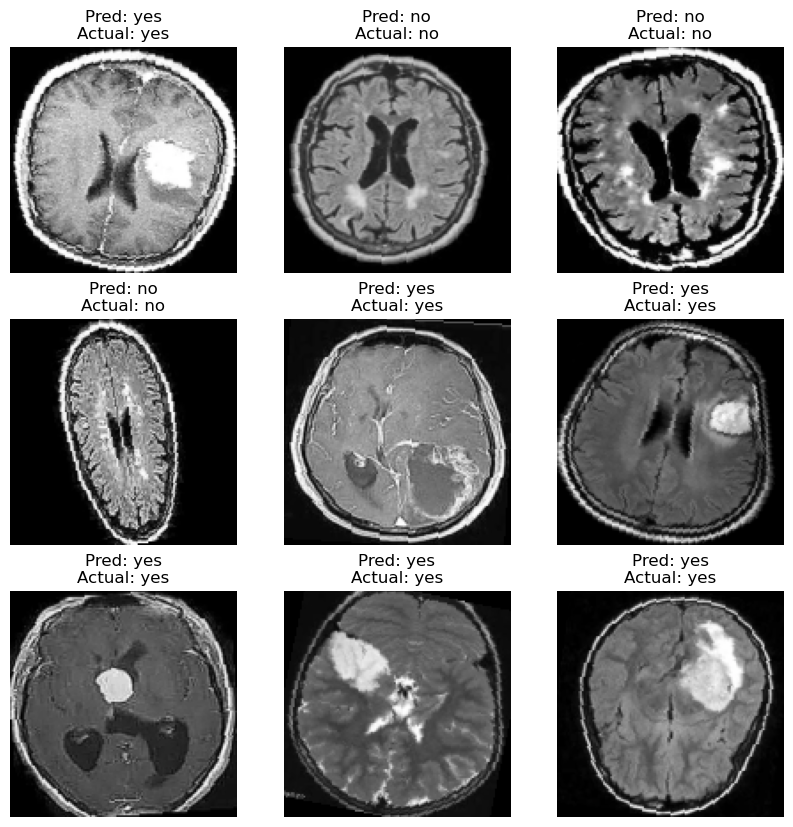

In [134]:
def show_test_predictions(loader, n=9):
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225], device=device).view(3,1,1)
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
    outputs = torch.sigmoid(model(images))
    preds = (outputs >= 0.5).int()

    plt.figure(figsize=(10,10))
    for i in range(n):
        img = images[i]
        img = img * std + mean
        img = torch.clamp(img, 0, 1)
        img = img.permute(1,2,0)  

        plt.subplot(3,3,i+1)
        plt.imshow(img.cpu())  
        plt.title(f"Pred: {train_data.classes[preds[i].item()]}\nActual: {train_data.classes[int(labels[i].item())]}")
        plt.axis("off")
    plt.show()

show_test_predictions(test_loader, n=9)

## 10. Logistic Regression for Comparison
Flatten images, convert to grayscale, train 

In [135]:
transform_lr = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(),      
    transforms.ToTensor()
])

train_data_lr = ImageFolder("dataset_split/train", transform=transform_lr)
val_data_lr = ImageFolder("dataset_split/val", transform=transform_lr)
test_data_lr = ImageFolder("dataset_split/test", transform=transform_lr)

def flatten_dataset(dataset):
    X, y = [], []
    for img, label in dataset:
        X.append(img.view(-1).numpy()) 
        y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = flatten_dataset(train_data_lr)
X_val, y_val = flatten_dataset(val_data_lr)
X_test, y_test = flatten_dataset(test_data_lr)


## 11. Train & Evaluate LR


Train Metrics:
              precision    recall  f1-score   support

          no       0.96      0.96      0.96      1500
         yes       0.96      0.96      0.96      1500

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000


Validation Metrics:
              precision    recall  f1-score   support

          no       0.96      0.96      0.96      1194
         yes       0.96      0.96      0.96      1213

    accuracy                           0.96      2407
   macro avg       0.96      0.96      0.96      2407
weighted avg       0.96      0.96      0.96      2407


Test Metrics:
              precision    recall  f1-score   support

          no       0.96      0.96      0.96      1206
         yes       0.96      0.96      0.96      1206

    accuracy                           0.96      2412
   macro avg       0.96      0.96      0.96      2412
weighted avg       0.9

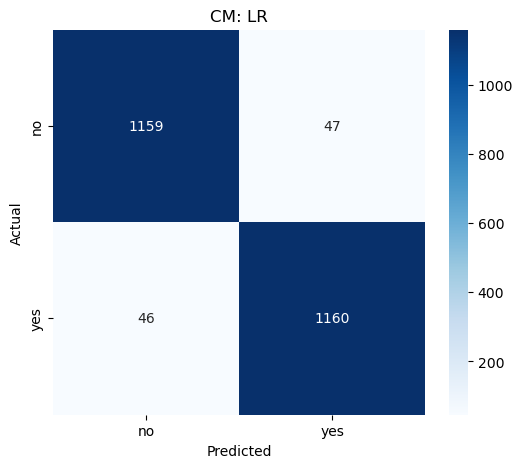

In [ ]:
logreg = LogisticRegression(max_iter=2000, solver='saga', C=1.0, n_jobs=-1)
logreg.fit(X_train, y_train)

for name, X, y in [('Train', X_train, y_train), ('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    pred = logreg.predict(X)
    print(f"\n{name} Metrics:")
    print(classification_report(y, pred, target_names=train_data_lr.classes))

cm = confusion_matrix(y_test, logreg.predict(X_test))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_data_lr.classes,
            yticklabels=train_data_lr.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CM: LR")
plt.show()

## 12. Comparison of CNN and LR

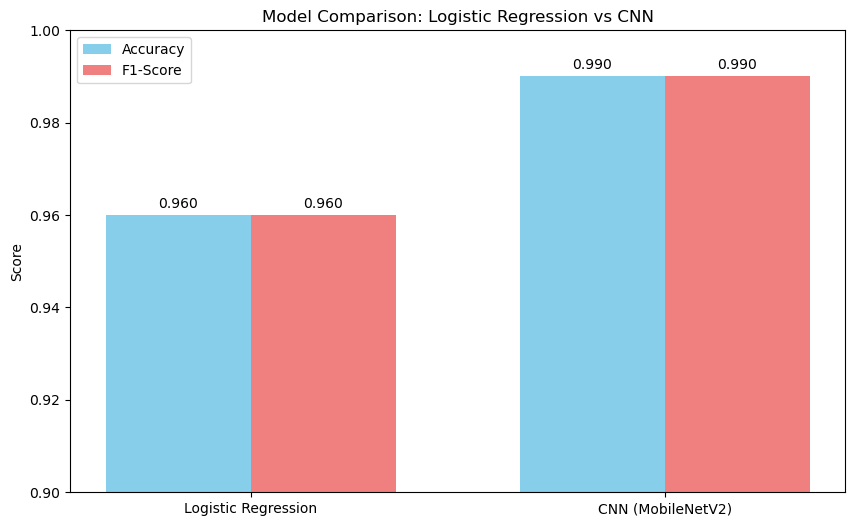

In [137]:
models = ['Logistic Regression', 'CNN (MobileNetV2)']
accuracies = [0.96, 0.99]
f1_scores = [0.96, 0.99]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='lightcoral')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Logistic Regression vs CNN')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim([0.9, 1.0])

for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.show()